# Chapter 109 — Rotation

> **Prerequisites:** ch103 (Unit Circle), ch108 (Transformations)
>
> **Outcomes:** Derive the 2D rotation matrix from first principles; Implement rotation around arbitrary centers; Compose multiple rotations; Connect to eigenvectors (preview)


## Derivation of the Rotation Matrix

Rotating point P = (x, y) by angle θ around the origin:

Using complex number multiplication (ch103):
(x + iy) · (cos θ + i sin θ) = (x cos θ - y sin θ) + i(x sin θ + y cos θ)

Therefore the rotated point is:
x' = x cos θ - y sin θ
y' = x sin θ + y cos θ

In matrix form: **[x'; y'] = R(θ) · [x; y]**

where the **rotation matrix** is:
R(θ) = [[cos θ, -sin θ], [sin θ, cos θ]]

**Properties:**
- R(0) = I (identity)
- R(θ)·R(φ) = R(θ+φ) — composition is angle addition
- R(θ)⁻¹ = R(-θ) = R(θ)ᵀ — inverse is transpose (orthogonal matrix)
- det(R) = cos²θ + sin²θ = 1 — rotation preserves area

*(det and orthogonal matrices formalized in ch158–159; eigenvalues of R in ch170.)*

R·R⁻¹ = I? True
R⁻¹ = Rᵀ? True
det(R) = 1.0


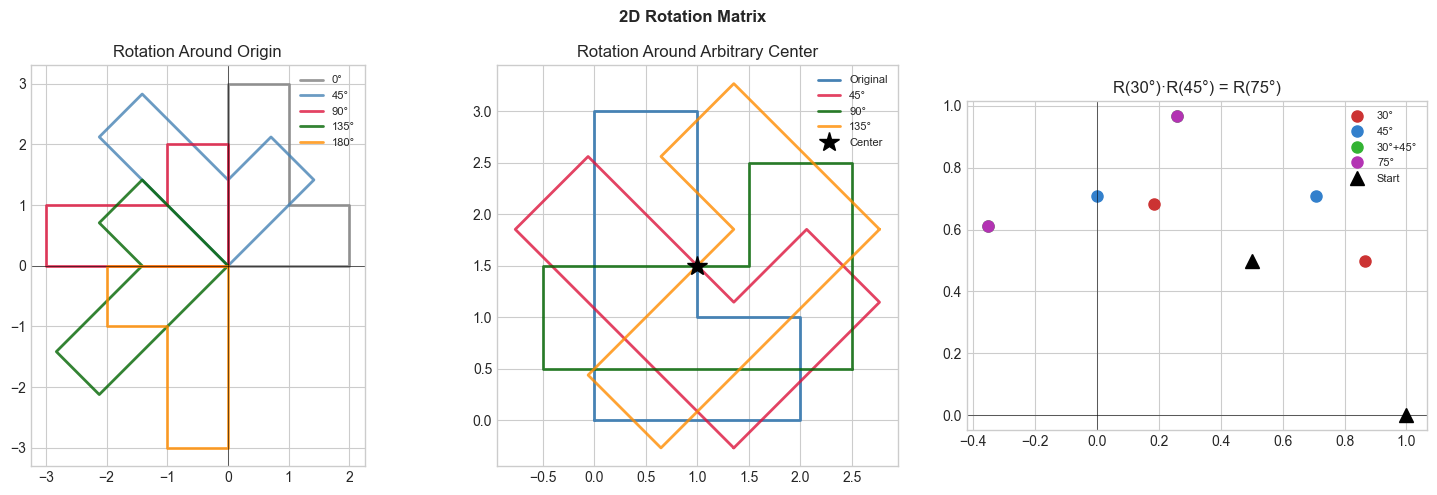

In [3]:
# --- Rotation matrix implementation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def rotation_matrix(theta):
    """2D rotation matrix for angle theta (radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def rotate_points(points, theta, center=(0,0)):
    """Rotate an (N,2) array by theta around center."""
    pts = np.asarray(points, dtype=float) - np.array(center)
    R = rotation_matrix(theta)
    return (R @ pts.T).T + np.array(center)

# L-shaped polygon
L_shape = np.array([[0,0],[2,0],[2,1],[1,1],[1,3],[0,3],[0,0]], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Rotation around origin
ax = axes[0]
colors = ['gray','steelblue','crimson','darkgreen','darkorange']
for angle_deg, color in zip([0, 45, 90, 135, 180], colors):
    rotated = rotate_points(L_shape, np.radians(angle_deg))
    ax.plot(rotated[:,0], rotated[:,1], color=color, lw=2, alpha=0.8, label=f'{angle_deg}°')
ax.set_aspect('equal'); ax.set_title('Rotation Around Origin'); ax.legend(fontsize=8)
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)

# Rotation around arbitrary center
ax = axes[1]
center = np.array([1.0, 1.5])
ax.plot(L_shape[:,0], L_shape[:,1], 'steelblue', lw=2, label='Original')
for angle_deg, color in [(45,'crimson'),(90,'darkgreen'),(135,'darkorange')]:
    rotated = rotate_points(L_shape, np.radians(angle_deg), center=center)
    ax.plot(rotated[:,0], rotated[:,1], color=color, lw=2, alpha=0.8, label=f'{angle_deg}°')
ax.plot(*center, 'k*', markersize=15, label='Center')
ax.set_aspect('equal'); ax.set_title('Rotation Around Arbitrary Center'); ax.legend(fontsize=8)

# Verify R(-θ) = R(θ)^T = R(θ)^(-1)
ax = axes[2]
theta = np.radians(37)
R = rotation_matrix(theta)
R_inv = rotation_matrix(-theta)
print("R·R⁻¹ = I?", np.allclose(R @ R_inv, np.eye(2)))
print("R⁻¹ = Rᵀ?", np.allclose(R_inv, R.T))
print("det(R) =", np.linalg.det(R).round(10))

# Show sequential rotation = sum of angles
pts = np.array([[1,0],[0.5,0.5]])
for angles, color, lbl in [([30],[0.8,0.2,0.2],'30°'),
                             ([45],[0.2,0.5,0.8],'45°'),
                             ([30,45],[0.2,0.7,0.2],'30°+45°'),
                             ([75],[0.7,0.2,0.7],'75°')]:
    result = pts.copy()
    for a in angles:
        result = rotate_points(result, np.radians(a))
    ax.plot(result[:,0],result[:,1],'o',color=color,markersize=8,label=lbl)
ax.plot(pts[:,0],pts[:,1],'k^',markersize=10,label='Start')
ax.set_aspect('equal'); ax.set_title('R(30°)·R(45°) = R(75°)')
ax.legend(fontsize=8); ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)

plt.suptitle('2D Rotation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

- R(θ) = [[cos θ, -sin θ],[sin θ, cos θ]] — derived from complex multiplication
- R(θ)·R(φ) = R(θ+φ); R(θ)⁻¹ = R(θ)ᵀ; det(R) = 1
- Rotation around arbitrary center: translate to origin, rotate, translate back
- R is an **orthogonal matrix**: its columns are orthonormal (Part VI, ch158)

**Forward:** ch113 shows how to compose rotation with other transforms in one matrix product;
ch169 (Eigenvalues) reveals that R(θ) has complex eigenvalues e^(±iθ).